In [313]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.cluster.hierarchy import DisjointSet
import math

In [233]:
omega = 0.4
n = 20
T = 15

def signal(x):
    return np.sin(omega*x)

#sample signal
def sample(signal, num):
    xs = np.sort(15*np.random.rand(num))
    ys = signal(xs)+0.05*np.random.randn(num)
    return xs,ys


In [284]:
class PIECEWISE:
    def __init__(self, xb, yb):
        self.xb = xb
        self.yb = yb
        self.n = len(xb)
        if len(self.yb) != self.n: return "error: x and y mismatch"

        self.m = []
        self.b = []
        for i in range(self.n-1):
            self.m.append(m)
            self.b.append(b)

    def estimate(self, t):
        if t> xb[-1] or t < xb[0]:
            return "error: out of range"

    def MSE_signal(self, signal):
        total = 0
        for i in range(self.n - 1):
            m = (self.yb[i+1] - self.yb[i])/(self.xb[i+1] - self.xb[i])
            b = self.yb[i] - m*self.xb[i]
            curr, curre = quad( lambda t: (signal(t) - (m*t+b))**2, self.xb[i], self.xb[i+1])
            total+= curr
        
        return (100*total/(self.xb[-1]-self.xb[0]))

    def MSE_points(self,xs,ys):
        if xs[0] < self.xb[0] or xs[-1] > self.xb[-1]: 
            return "error: out of range"
        
        j = 0
        total = 0
        for i in range(len(xs)):
            while xs[i] > self.xb[j+1]:
                j+=1
            m = (self.yb[j+1] - self.yb[j])/(self.xb[j+1] - self.xb[j])
            b = self.yb[j] - m*self.xb[j]

            total += (ys[i] - m*xs[i] - b)**2

        return total / len(xs)

    def plot(self):
        plt.scatter(self.xb, self.yb, s = 10)
        plt.plot(self.xb, self.yb)
    

In [441]:
class SAMPLE:
    def __init__(self, num, signal):
        self.n = num
        self.signal = signal
        self.resample(num)
        self.xt = np.linspace(0,T,1000)
        self.yt = signal(xt)

    def resample(self,num):
        self.xs = np.sort(15*np.random.rand(num))
        self.ys = signal(self.xs)+0.05*np.random.randn(num)

    def cluster_fit(self,indices):
        
        ms = []
        bs = []
        for i in range(len(indices)-1):
            I = indices[i]
            II = indices[i+1]
            XS = self.xs[I:II]
            YS = self.ys[I:II]

            OS = np.ones(len(XS))

            XMAT = np.vstack((XS,OS)).T
            [M,B] = np.linalg.solve(XMAT.T @ XMAT, XMAT.T @ np.array(YS))

            ms.append(M)
            bs.append(B)
        I = indices[-1]
        XS = self.xs[I:]
        YS = self.ys[I:]
        OS = np.ones(len(XS))

        XMAT = np.vstack((XS,OS)).T
        [M,B] = np.linalg.solve(XMAT.T @ XMAT, XMAT.T @ np.array(YS))

        ms.append(M)
        bs.append(B)
        

        xb = [self.xs[0]]
        yb = [ms[0]*self.xs[0]+bs[0]]

        for i in range(len(ms)-1):
            m1 = ms[i]
            m2 = ms[i+1]
            b1 = bs[i]
            b2 = bs[i+1]

            xb.append((b2-b1)/(m1-m2))
            yb.append((m2*b1 - m1*b2)/(m2-m1))

        xb.append(self.xs[-1])
        yb.append(ms[-1]*self.xs[-1]+bs[-1])
            
        return PIECEWISE(xb,yb)

    def plot_signal(self):

        connected_fit = PIECEWISE(self.xs, self.ys)
        mse = connected_fit.MSE_signal(self.signal)
        
        plt.title(f'n = {self.n}, MSE = {mse}')
        # plt.scatter(self.xs,self.ys,s=5)
        # plt.plot(self.xs,self.ys,color='black', linewidth=0.5)
        plt.plot(self.xt,self.yt, '--', color = 'orange')
        # plt.show()

    def plot_cluster(self, indices):
        for i in range(len(indices)-1):
            I = indices[i]
            II = indices[i+1]
            XS = self.xs[I:II]
            YS = self.ys[I:II]
            plt.scatter(XS,YS, s= 10)

        plt.scatter(self.xs[indices[-1]:], self.ys[indices[-1]:], s=10)
    
    # we have N points, want K clusters, and require at least M points in each cluster
    def all_subarrays(self,start, N, M, K):
        if K == 1:
            return [[start]]

        if M*K > N-start: #breaking criterion -- you've requested an infeasible input
            return []
    
        arrays = []
        for i in range(start+M, N-(K-1)*M+1):
            curr = self.all_subarrays(i, N, M, K-1)
            for arr in curr:
                arr.append(start)
            arrays.extend(curr)
        return arrays

    def find_optimal_Kclustering(self, M, K):
        print(math.comb(self.n - M*K + K - 1, K-1))
        if math.comb(self.n - M*K + K - 1, K-1) > 10**8:
            return "sorry, no"
        options = self.all_subarrays(0, self.n, M, K)

        best_MSE = 10
        best_option = None
        bad_count = 0
        for option in options:
            option.reverse()
            estimator = self.cluster_fit(option)
            if sorted(estimator.xb) != estimator.xb:
                bad_count+=1
                continue
            
            mse = estimator.MSE_points(self.xs, self.ys)
           
            if mse < best_MSE:
                
                best_option = option
                best_MSE = mse
        
        return best_option
    

780
[0, 14, 35]


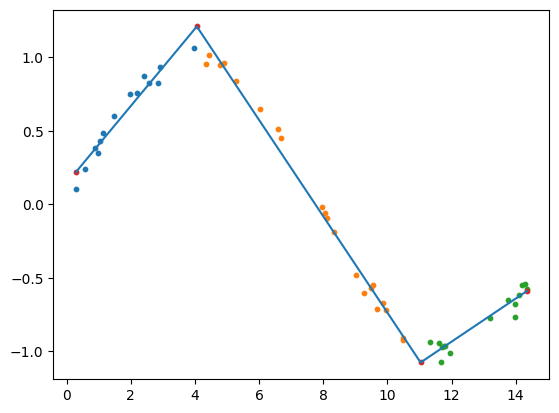

7770
[0, 13, 19, 35]


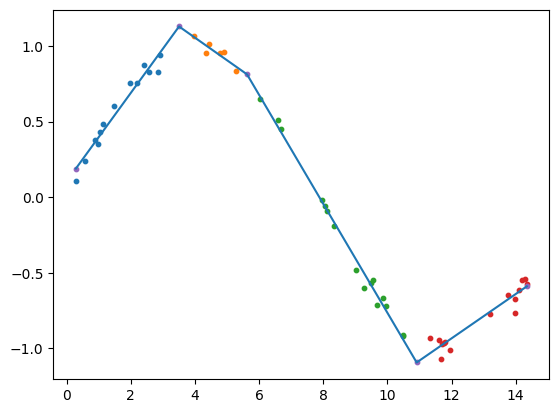

46376
[0, 7, 13, 19, 35]


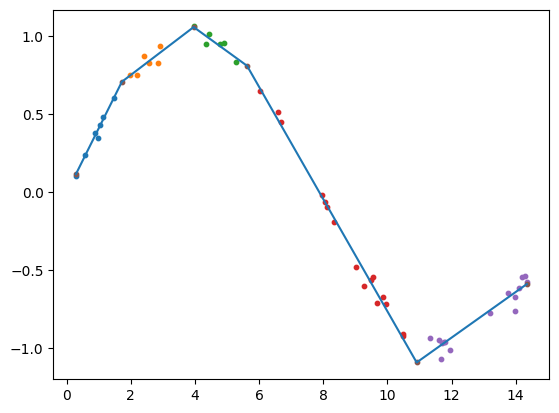

169911
[0, 7, 13, 19, 33, 42]


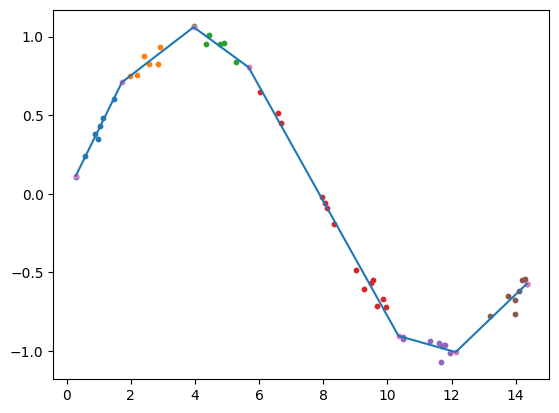

376740
[0, 7, 14, 20, 27, 34, 42]


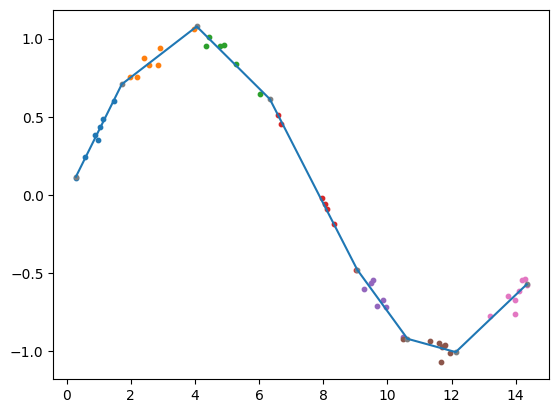

480700
[0, 7, 13, 18, 22, 27, 34, 42]


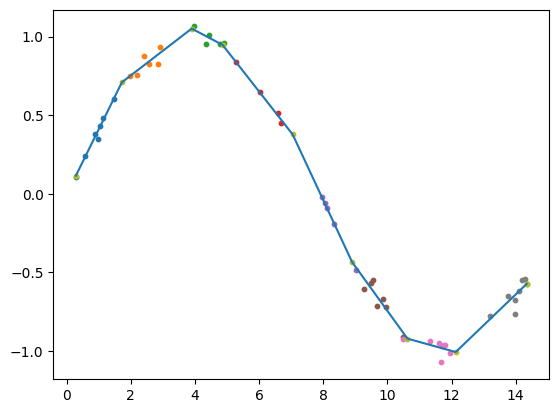

319770
[0, 7, 13, 18, 22, 27, 34, 39, 43]


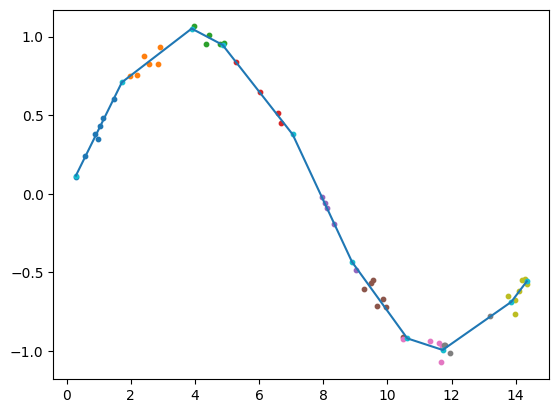

92378
[0, 7, 13, 18, 22, 27, 31, 35, 41, 45]


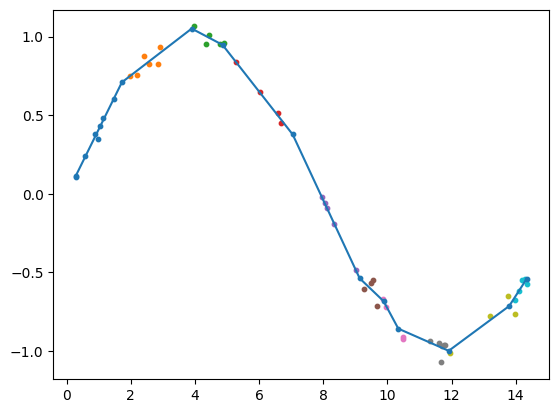

8008
[0, 4, 8, 13, 18, 22, 27, 31, 35, 41, 45]


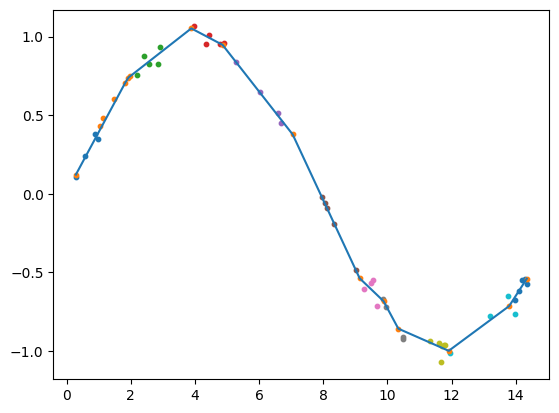

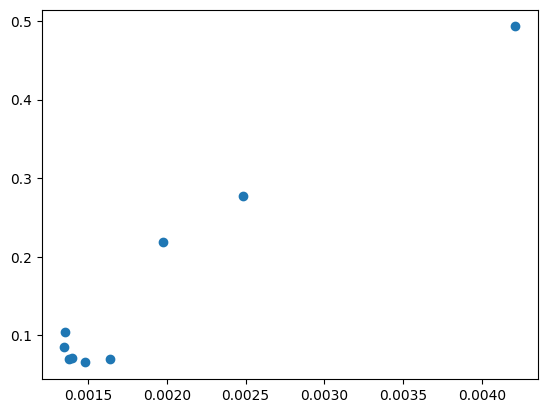

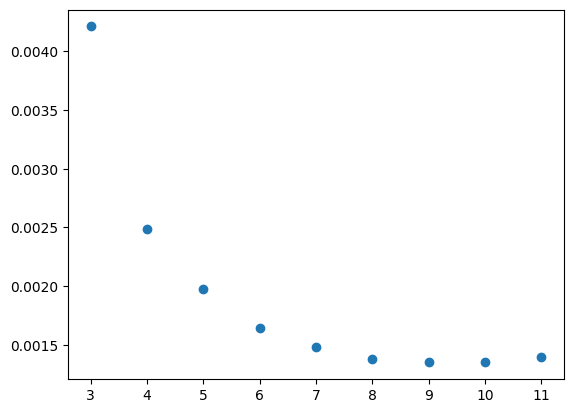

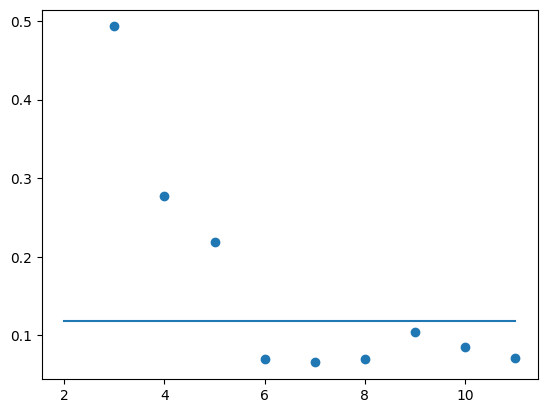

In [446]:
sample = SAMPLE(50,signal)

Ks = [3,4,5,6,7,8,9,10,11]
pointMSEs = []
signalMSEs = []
connected_fit = PIECEWISE(sample.xs, sample.ys)
naive_mse = connected_fit.MSE_signal(sample.signal)
for K in Ks:
    clustering = sample.find_optimal_Kclustering(4,K)
    print(clustering)
    best_estimator = sample.cluster_fit(clustering)
    sample.plot_cluster(clustering)
    best_estimator.plot()
    plt.show()
    signal_mse = best_estimator.MSE_signal(sample.signal)
    point_mse = best_estimator.MSE_points(sample.xs, sample.ys)
    signalMSEs.append(signal_mse)
    pointMSEs.append(point_mse)
    
plt.scatter(pointMSEs, signalMSEs)
plt.show()

plt.scatter(Ks, pointMSEs)
plt.show()

plt.scatter(Ks, signalMSEs)
plt.plot([2,11], [naive_mse, naive_mse])
plt.show()


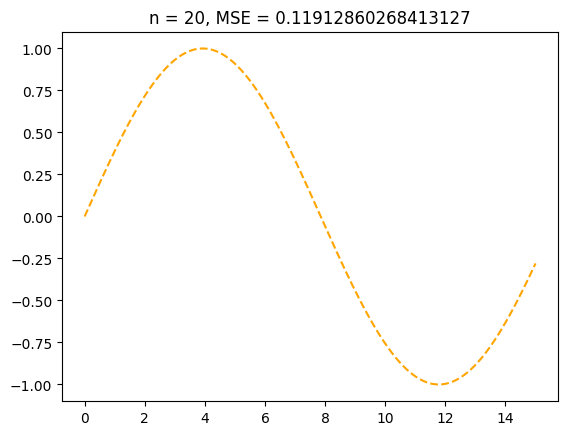

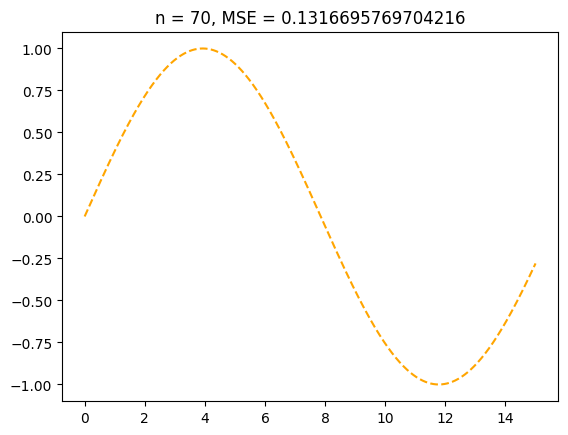

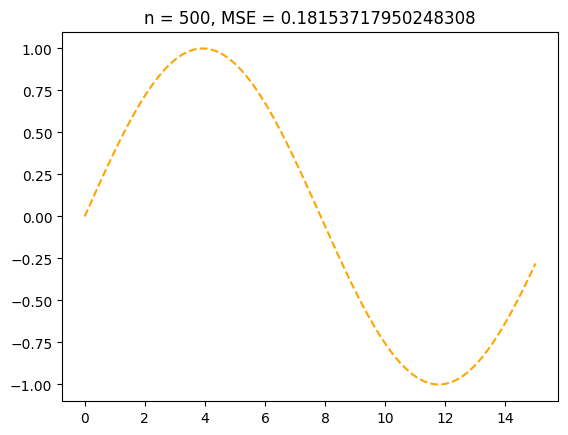

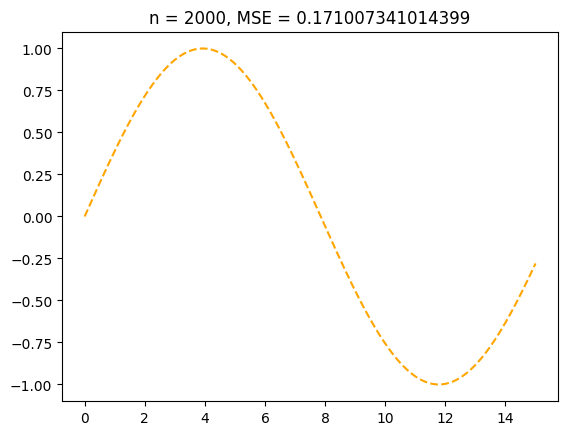

In [365]:
for num in [20,70,500,2000]:
    sample = SAMPLE(num, signal)
    sample.plot_signal()
    plt.show()

In [209]:
def kCluster(xs, k):
    n = len(xs)

    edges = []
    for i in range(n-1):
        edges.append((i,i+1))

    edges.sort(key = lambda edge: xs[edge[1]] - xs[edge[0]])
    
    clusters = DisjointSet(range(n))

    count = n
    i = 0
    while count > k:
            
        p1 = edges[i][0]
        p2 = edges[i][1]
        
        if not clusters.connected(p1,p2):
            clusters.merge(p1,p2)
            count-=1

        i+=1

    return clusters

1
51
150
5
45
27
3
5
69
16
5
33
53
9
28


/var/folders/s3/rl7pd8bd54g2b20s8l3xmd180000gn/T/ipykernel_67835/2165909989.py:20: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(xs[j:k], ys[j:k], 1)


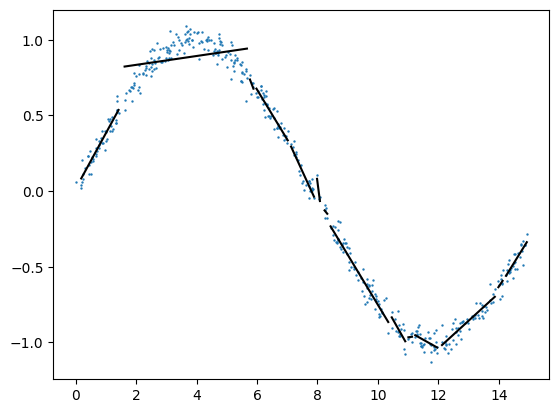

In [210]:
# using the k-clustering algorithm from homework 2

xs, ys = sample(signal, 500)
plt.scatter(xs,ys,s=0.5)
# plt.plot(xs,ys)
# plt.plot(xt,yt)

clusters = kCluster(xs, 15)
start_indices = [0]
for subset in clusters.subsets():
    print(len(subset))
    start_indices.append(start_indices[-1] + len(subset))

for i in range(len(start_indices)-1):
    j = start_indices[i]
    k = start_indices[i+1]

    xs[j:k]
    ys[j:k]
    m, b = np.polyfit(xs[j:k], ys[j:k], 1)
    line = m*xs[j:k] + b
    
    plt.plot(xs[j:k], line, color = 'black')

plt.show()

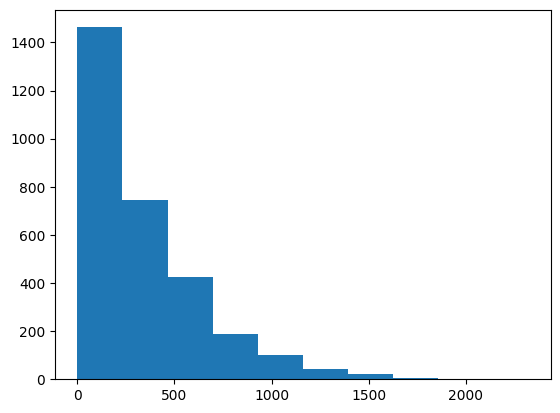

333.3333333333333 98420.35288888891


In [211]:
# this turns out to be DOODOO
# because we get a ton of tiny clusters and a handful of big ones
# see histogram of clustrer sizes below OR the example graph above
n = 5000
k = 15
trials = 200

sizes = []
for i in range(trials):
    xs, ys = sample(signal, n)
    clusters = kCluster(xs, k)
    for subset in clusters.subsets():
        sizes.append(len(subset))

plt.hist(sizes)
plt.show()
print(np.mean(sizes), np.var(sizes))

In [213]:
for i in enumerate([1,2,3]):
    print(i)

(0, 1)
(1, 2)
(2, 3)


In [297]:
xs = [1,2,3,4]
ys = [5,6,7,9]
os = np.ones(len(xs))

X = np.vstack((xs,os)).T
[m,b] = np.linalg.solve(X.T @ X,X.T @ np.array(ys))
print(m)

1.2999999999999996


In [395]:
Key = [4,6,2]

opts = [[4,6,2], [1,2,3]]

print(Key in opts)

True
